In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, GRU, Dense, Dropout, SimpleRNN
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

2026-04-10 16:41:28.025433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775839288.421098      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775839288.529915      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775839289.488979      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775839289.489039      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775839289.489045      55 computation_placer.cc:177] computation placer alr

In [2]:
data=pd.read_csv('/kaggle/input/datasets/deepakjoshi78/tweets/Tweets.csv')
data.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [4]:
data.isnull().sum()

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

In [5]:
# clean text + encode labels
texts = data['text'].fillna('').astype(str).values
labels = LabelEncoder().fit_transform(data['sentiment'])

# split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=43, stratify=labels
)

# BERT tokenize
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_len = 50

X_train = tokenizer(
    list(X_train_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

X_test = tokenizer(
    list(X_test_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
%%time
vocab_size = int(max(X_train.max(), X_test.max())) + 1

def build_rnn():
    model = Sequential([
        Embedding(vocab_size, 128),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(vocab_size, 128),
        LSTM(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_gru():
    model = Sequential([
        Embedding(vocab_size, 128),
        GRU(128),
        Dense(3, activation='softmax')
    ])
    return model

CPU times: user 2.03 ms, sys: 784 µs, total: 2.81 ms
Wall time: 2.31 ms


In [7]:
models = {
    'RNN': build_rnn(),
    'LSTM': build_lstm(),
    'GRU': build_gru()
}

results = {}

for name, model in models.items():
    print(f'Training {name} model...')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    start = time.time()
    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping]
    )

    end = time.time()
    results[name] = {
        'history': history,
        'training_time': end - start
    }

Training RNN model...
Epoch 1/10


I0000 00:00:1775839340.990733      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775839340.996537      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775839342.868751     138 service.cc:152] XLA service 0x7edcf80035c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775839342.868801     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775839342.868805     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775839343.475425     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


 25/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4128 - loss: 1.0952

I0000 00:00:1775839345.298189     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3783 - loss: 1.1056 - val_accuracy: 0.4046 - val_loss: 1.0978
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3835 - loss: 1.0997 - val_accuracy: 0.4512 - val_loss: 1.0530
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4246 - loss: 1.0688 - val_accuracy: 0.4566 - val_loss: 1.0331
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4687 - loss: 1.0285 - val_accuracy: 0.4182 - val_loss: 1.0589
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4672 - loss: 1.0210 - val_accuracy: 0.4524 - val_loss: 1.0455
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4403 - loss: 1.0523 - val_accuracy: 0.3822 - val_loss: 1.0888
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4036 - loss: 1.0760 - val_accuracy: 0.4131 - val_loss: 1.0849
Training LSTM model...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4112 - loss: 1.0878 - va

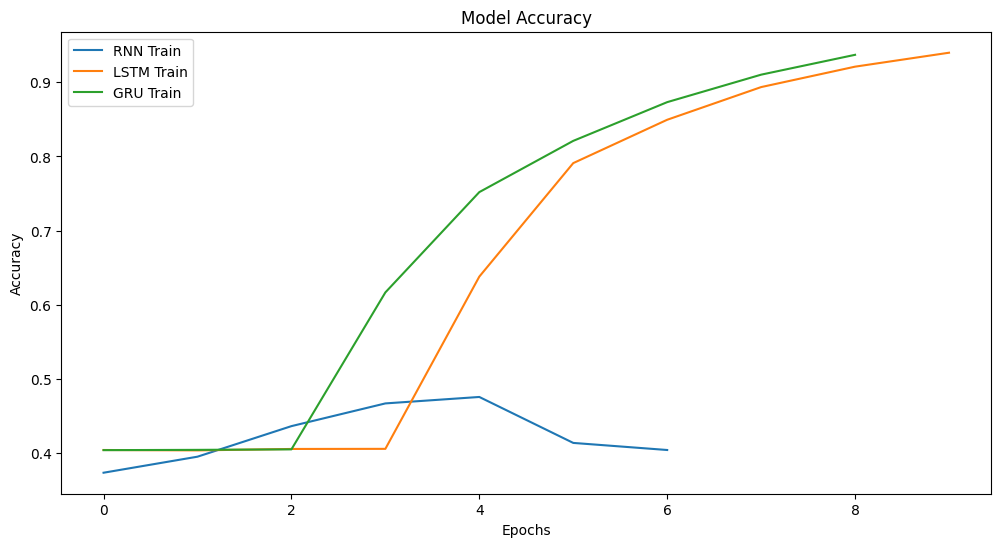

In [8]:
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result['history'].history['accuracy'], label=f'{name} Train')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

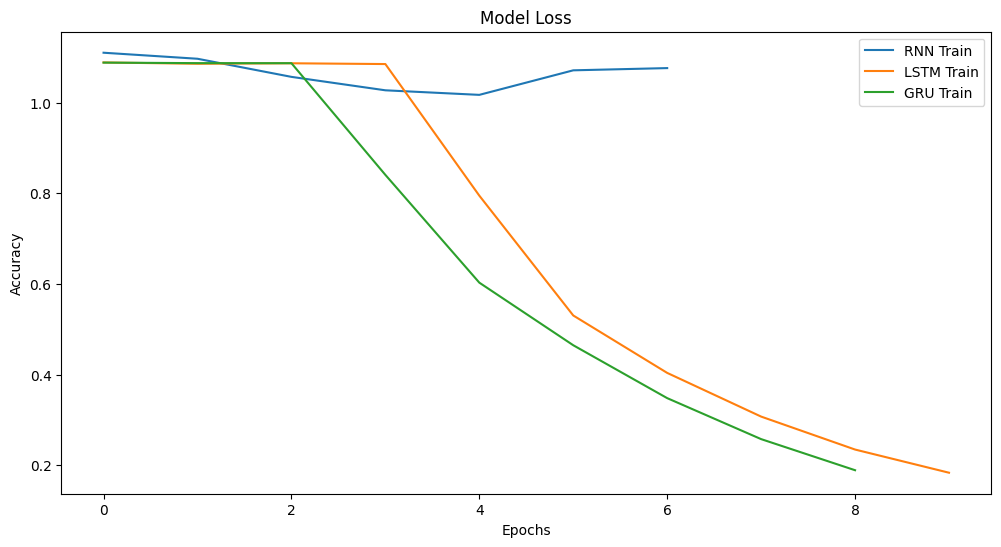

In [9]:
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result['history'].history['loss'], label=f'{name} Train')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [10]:
Sequence = [10, 20, 40, 60, 80]
rnn_acc, lstm_acc, gru_acc = [], [], []

for l in Sequence:
    print(f'Testing sequence length: {l}')
    
    X_train_l = tokenizer(
        list(X_train_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    X_test_l = tokenizer(
        list(X_test_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    vocab_size_l = int(max(X_train_l.max(), X_test_l.max())) + 1

    rnn_model = Sequential([
        Embedding(vocab_size_l, 128),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])

    lstm_model = Sequential([
        Embedding(vocab_size_l, 128),
        LSTM(128),
        Dense(3, activation='softmax')
    ])

    gru_model = Sequential([
        Embedding(vocab_size_l, 128),
        GRU(128),
        Dense(3, activation='softmax')
    ])

    model_map = {
        'RNN': rnn_model,
        'LSTM': lstm_model,
        'GRU': gru_model
    }

    for model_name, model_obj in model_map.items():
        model_obj.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        es = EarlyStopping(
            monitor='val_loss',
            patience=1,
            restore_best_weights=True
        )

        model_obj.fit(
            X_train_l,
            y_train,
            epochs=3,
            batch_size=64,
            validation_data=(X_test_l, y_test),
            callbacks=[es],
            verbose=0
        )

        _, test_acc = model_obj.evaluate(X_test_l, y_test, verbose=0)

        if model_name == 'RNN':
            rnn_acc.append(test_acc)
        elif model_name == 'LSTM':
            lstm_acc.append(test_acc)
        else:
            gru_acc.append(test_acc)

print('RNN accuracies:', rnn_acc)
print('LSTM accuracies:', lstm_acc)
print('GRU accuracies:', gru_acc)

Testing sequence length: 10
Testing sequence length: 20
Testing sequence length: 40
Testing sequence length: 60
Testing sequence length: 80
RNN accuracies: [0.5928688645362854, 0.6159723401069641, 0.6181553602218628, 0.4045843183994293, 0.4045843183994293]
LSTM accuracies: [0.6061487793922424, 0.6821902990341187, 0.7285792231559753, 0.4045843183994293, 0.4045843183994293]
GRU accuracies: [0.6070584058761597, 0.6843733191490173, 0.7416772842407227, 0.4045843183994293, 0.4045843183994293]
